# District‑level crop yield prediction using machine learning

**MSc Data Science Project – 7PAM2002-0206-2025**  

**Student:** BUREBOINA VAMSHI  

**SRN:** 24085801

**GitHub repository:** https://github.com/vamshi-34/Crop_Prediction
## Research problem

The central research question of this project is:

> To what extent can tree‑based machine‑learning models trained solely on APY statistics accurately predict district‑level crop yields in India, and how do they compare with a linear regression baseline?

The notebook implements the full pipeline used to answer this question.

## Dataset overview

The analysis uses the Indian Area, Production and Yield (APY) dataset, where each row corresponds to a combination of state, district, crop, season and crop year. The main columns are:

- **State** – name of the Indian state or union territory.  
- **District** – name of the district within the state.  
- **Crop** – crop name (e.g. rice, wheat, sugarcane, coconut).  
- **Crop_Year** – crop year (e.g. 1997, 2010, 2019).  
- **Season** – cropping season (e.g. Kharif, Rabi, Summer, Whole Year).  
- **Area** – cultivated area in hectares.  
- **Production** – total production in tonnes.  
- **Yield** – derived yield in tonnes per hectare (Production divided by Area).

In the Indian context, **Kharif** refers to the monsoon cropping season, with crops typically sown from **June–July** and harvested around **September–October**, while **Rabi** refers to the before winter season, with crops sown from **October–November** and harvested around **April–May**.

## Notebook objectives

This notebook will:

- Load and clean the raw APY data, including handling missing values and implausible yield outliers.  
- Explore key patterns in yield across seasons, crops, states and years.  
- Encode categorical and numeric features, then train several models (Ridge, Random Forest and `HistGradientBoostingRegressor`).  
- Refine the tree‑based models, compare their test performance, and interpret feature importance for the best model to understand which factors drive yield predictions.

## 1. Data loading and initial inspection

In this section I load the APY dataset, check basic structure and data types, and confirm that the target variable (Yield) is suitable for supervised regression.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

# Load the dataset (update path if needed)
file_path = "APY.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (345336, 8)

Columns:
 Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')

Data types:
 State          object
District       object
Crop           object
Crop_Year       int64
Season         object
Area          float64
Production    float64
Yield         float64
dtype: object

First 5 rows:


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


## 2. Basic cleaning and sanity checks

Here I standardise column names, inspect missing values and basic descriptive statistics to understand data quality before modelling.

In [ ]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

print("Columns after stripping whitespace:\n", df.columns)

# Basic info and missing values
print("\nDataFrame info:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

# Descriptive statistics for numerical columns
print("\nDescriptive statistics (numerical features):")
display(df[["Area", "Production", "Yield"]].describe())

# Unique counts for key categorical variables
for col in ["State", "District", "Crop", "Season", "Crop_Year"]:
    print(f"\n{col} - unique values:", df[col].nunique())

Columns after stripping whitespace:
 Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area',
       'Production', 'Yield'],
      dtype='object')

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        345327 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  object 
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB
None

Missing values per column:
State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

Descriptive statistics (numerical 

,Area,Production,Yield
count,3.453360e+05,3.403880e+05,345336.000000
mean,1.167147e+04,9.584726e+05,79.423135
std,4.584079e+04,2.153068e+07,916.678396
min,4.000000e-03,0.000000e+00,0.000000
25%,7.400000e+01,8.700000e+01,0.550000
50%,5.320000e+02,7.170000e+02,1.000000
75%,4.112000e+03,7.182000e+03,2.470000
max,8.580100e+06,1.597800e+09,43958.330000



State - unique values: 37

District - unique values: 707

Crop - unique values: 55

Season - unique values: 6

Crop_Year - unique values: 24


2.1 Summary of initial inspection

- 345,336 rows and 8 columns, suitable for supervised learning.
- Categorical: State, District, Crop, Season; numeric: Area, Production, Yield; year: Crop_Year.
- Missing values only in Crop (9) and Production (4,948); Yield has no missing values.
- Area, Production and Yield are highly skewed with very large maxima.
- Yield has realistic central values but extreme upper outliers (up to 43,958 t/ha).

## 3. Handling extreme yields and missing values

I remove rows with missing Crop, non-positive yields, and extreme yield outliers before modelling.

In [ ]:
df_clean = df.copy()

# Drop rows with missing Crop
df_clean = df_clean[df_clean["Crop"].notna()]

# Keep only strictly positive yields
df_clean = df_clean[df_clean["Yield"] > 0]

# Inspect extreme yields
print("Top 10 yields:")
display(df_clean["Yield"].sort_values(ascending=False).head(10))

# Apply a conservative upper cap for yield (e.g. 200 t/ha)
yield_cap = 200
n_before = len(df_clean)
df_clean = df_clean[df_clean["Yield"] <= yield_cap]
n_after = len(df_clean)

print(f"\nRows before cap: {n_before:,}")
print(f"Rows after cap:  {n_after:,}")
print(f"Rows removed by yield cap (> {yield_cap}): {n_before - n_after:,}")

Top 10 yields:


,Yield
24551,43958.33
333525,38800.00
258896,33133.61
24552,32957.75
3122,31578.95
24548,30093.33
3229,29772.00
24549,28789.47
24303,28334.16
24402,26270.83



Rows before cap: 339,236
Rows after cap:  336,311
Rows removed by yield cap (> 200): 2,925


- Extremely large yield values are present, with a maximum around 43,958 t/ha.
- Applying a cap of 200 t/ha removes 2,925 rows (from 339,236 to 336,311), leaving a cleaner dataset for modelling.

## 4. Dataset for modelling and EDA

I use the cleaned dataset `df_clean` as the basis for EDA and model training.

### 4.1 Distributions of numerical variables


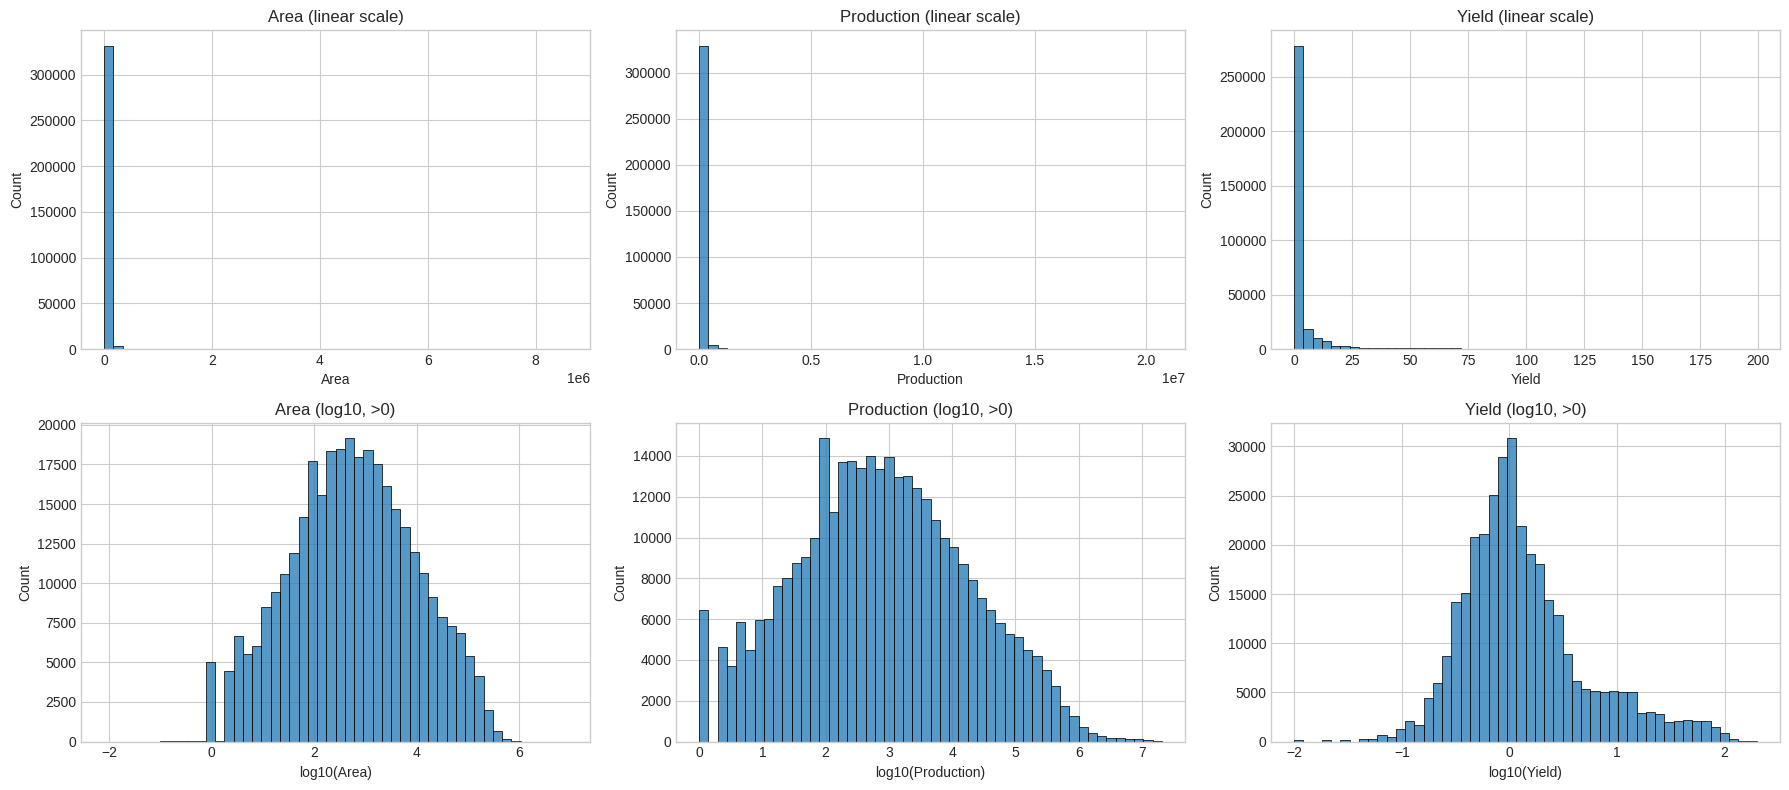

In [ ]:
df_model = df_clean.copy()  # or use your df_model if already defined

num_cols = ["Area", "Production", "Yield"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Linear scale histogram
    sns.histplot(df_model[col].dropna(), bins=50, ax=axes[0, i], kde=False)
    axes[0, i].set_title(f"{col} (linear scale)")

    # Log10 histogram for positive values
    positive_vals = df_model[col][df_model[col] > 0]
    sns.histplot(np.log10(positive_vals), bins=50, ax=axes[1, i], kde=False)
    axes[1, i].set_title(f"{col} (log10, >0)")
    axes[1, i].set_xlabel(f"log10({col})")

plt.tight_layout()
plt.show()


- On the original scale, Area, Production and Yield are heavily right‑skewed with many small values and a few very large ones.
- On the log10 scale, Area and Production become roughly symmetric, while Yield still shows a long upper tail.

### 4.2 Yield by season

I compare average yield across seasons to see when districts tend to be most productive.

['Autumn     ', 'Kharif     ', 'Rabi       ', 'Summer     ', 'Whole Year ', 'Winter     ']


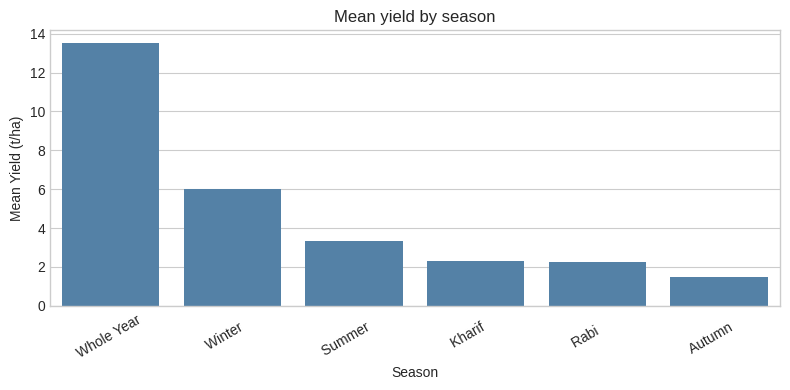

In [ ]:
# Check unique season values first
print(sorted(df_model["Season"].unique()))

season_yield = (
    df_model.groupby("Season")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=season_yield.index, y=season_yield.values, color="steelblue")
plt.ylabel("Mean Yield (t/ha)")
plt.xlabel("Season")
plt.title("Mean yield by season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

- Whole Year and Winter show the highest mean yields, followed by Summer.
- Kharif, Rabi and Autumn have lower average yields, so seasonal effects are quite pronounced.

### 4.3 Yield by crop (top 15)

I examine which crops have the highest and lowest average yields across districts.

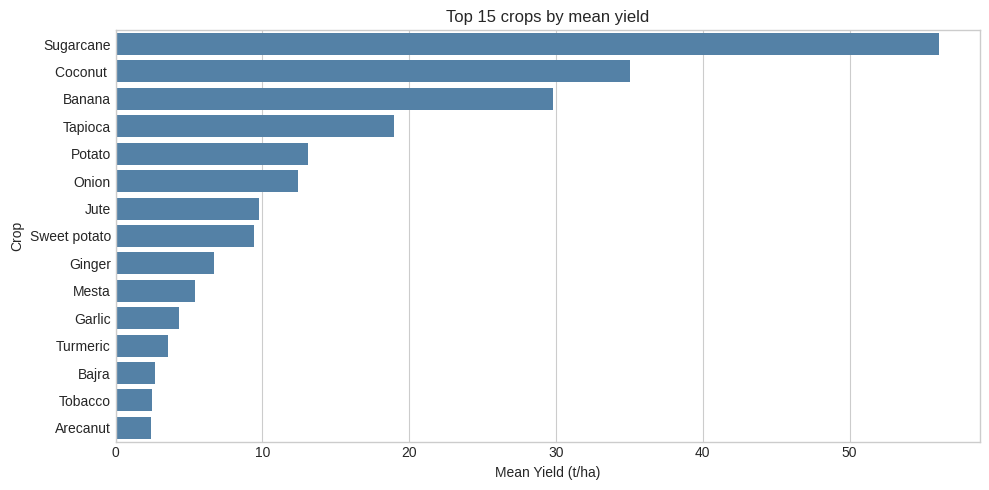

In [ ]:
# Mean yield by crop
crop_yield = (
    df_model.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

top_n = 15
top_crops = crop_yield.head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(
    y=top_crops.index,
    x=top_crops.values,
    color="steelblue"
)
plt.xlabel("Mean Yield (t/ha)")
plt.ylabel("Crop")
plt.title(f"Top {top_n} crops by mean yield")
plt.tight_layout()
plt.show()

- Sugarcane, Coconut, Banana and Tapioca show the highest average yields.
- Several root and fibre crops (e.g. Potato, Onion, Jute) also have notably higher yields than most other crops.

### 4.4 Yield over time

I look at how average yield has changed across crop years.

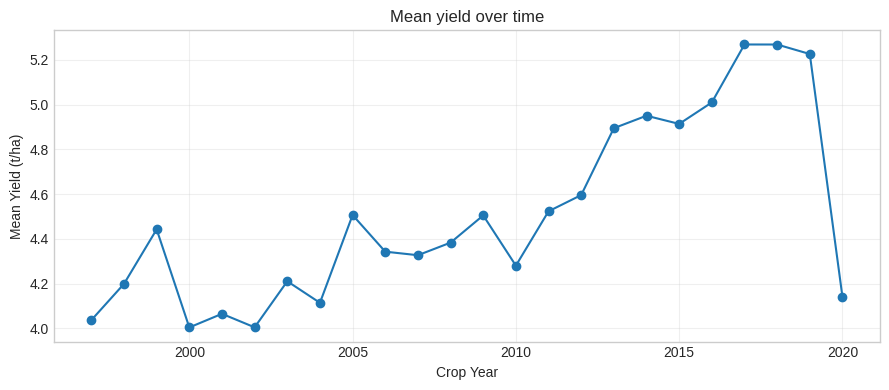

In [ ]:
year_yield = (
    df_model.groupby("Crop_Year")["Yield"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 4))
plt.plot(year_yield.index, year_yield.values, marker="o")
plt.xlabel("Crop Year")
plt.ylabel("Mean Yield (t/ha)")
plt.title("Mean yield over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Average yield increases gradually from around 4.0 t/ha in the late 1990s to over 5.0 t/ha after 2013.
- There is a noticeable dip in the final year, indicating recent variability or incomplete data.

### 4.5 Yield by state (top 15)

I compare average yields across states to capture spatial variation.

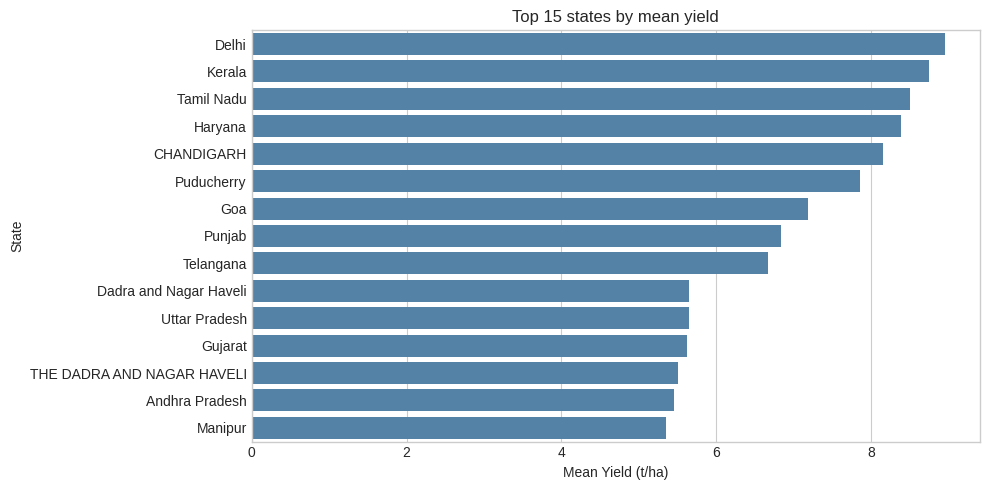

In [ ]:
state_yield = (
    df_model.groupby("State")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

top_n = 15
top_states = state_yield.head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(
    y=top_states.index,
    x=top_states.values,
    color="steelblue"
)
plt.xlabel("Mean Yield (t/ha)")
plt.ylabel("State")
plt.title(f"Top {top_n} states by mean yield")
plt.tight_layout()
plt.show()

- Delhi, Kerala and Tamil Nadu have the highest average yields among states and union territories.
- There is substantial variation across states, confirming strong spatial heterogeneity in district yields.

## 5. Train, validation and test split

I create a temporal split by crop year so that later years are held out for validation and testing.

### 5.1 Split summary

In [ ]:
# Check year range
print("Year range:", df_model["Crop_Year"].min(), "to", df_model["Crop_Year"].max())

# Example split: train 1997–2012, val 2013–2015, test 2016–2019
train_years = list(range(1997, 2013))
val_years   = list(range(2013, 2016))
test_years  = list(range(2016, 2020))

train_df = df_model[df_model["Crop_Year"].isin(train_years)].copy()
val_df   = df_model[df_model["Crop_Year"].isin(val_years)].copy()
test_df  = df_model[df_model["Crop_Year"].isin(test_years)].copy()

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

Year range: 1997 to 2020
Train size: 217480
Val size:   47085
Test size:  71427


- Crop years span 1997 to 2020 in the cleaned dataset.
- The split gives 217,480 training rows, 47,085 validation rows and 71,427 test rows using later years as hold‑out sets.

## 6. Feature encoding and design matrix

I encode categorical variables and assemble numeric feature matrices and target vectors for each split.

6.1 Define feature sets and target

In [ ]:
# Categorical and numeric predictors
cat_cols = ["State", "District", "Crop", "Season"]
num_cols = ["Area", "Production", "Crop_Year"]

target_col = "Yield"

# Drop any remaining missing values in features
for df_part, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    missing = df_part[cat_cols + num_cols].isna().sum()
    print(f"\nMissing feature values in {name} set:")
    print(missing[missing > 0])


Missing feature values in train set:
Series([], dtype: int64)

Missing feature values in val set:
Series([], dtype: int64)

Missing feature values in test set:
Series([], dtype: int64)


- All selected feature columns are complete in the train, validation and test splits.
- The target variable is Yield, with 4 categorical and 3 numeric predictors.


6.2 Ordinal encoding for categoricals

In [ ]:
# Use the cleaned modelling dataset
df_model = df_clean.copy()

# Year-based split
train_years = list(range(1997, 2013))
val_years   = list(range(2013, 2016))
test_years  = list(range(2016, 2020))

train_df = df_model[df_model["Crop_Year"].isin(train_years)].copy()
val_df   = df_model[df_model["Crop_Year"].isin(val_years)].copy()
test_df  = df_model[df_model["Crop_Year"].isin(test_years)].copy()

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

Train size: 217480
Val size:   47085
Test size:  71427


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit on training set categoricals
train_cat = train_df[cat_cols]
val_cat   = val_df[cat_cols]
test_cat  = test_df[cat_cols]

encoder.fit(train_cat)

train_cat_enc = encoder.transform(train_cat)
val_cat_enc   = encoder.transform(val_cat)
test_cat_enc  = encoder.transform(test_cat)

# Numerical parts
train_num = train_df[num_cols].values
val_num   = val_df[num_cols].values
test_num  = test_df[num_cols].values

# Design matrices
train_X = np.hstack([train_cat_enc, train_num])
val_X   = np.hstack([val_cat_enc,   val_num])
test_X  = np.hstack([test_cat_enc,  test_num])

# Targets
train_y = train_df[target_col].values
val_y   = val_df[target_col].values
test_y  = test_df[target_col].values

print("Train X shape:", train_X.shape)
print("Val   X shape:", val_X.shape)
print("Test  X shape:", test_X.shape)

Train X shape: (217480, 7)
Val   X shape: (47085, 7)
Test  X shape: (71427, 7)


- After encoding categoricals and combining with numeric features, the design matrices have 7 columns.
- The final shapes are 217,480 rows for training, 47,085 for validation and 71,427 for testing.

## 7. Modelling – initial models

I first train three baseline models on the encoded features: Ridge regression, Random Forest and HistGradientBoostingRegressor.

7.1 Helper for evaluation

In [ ]:
from sklearn.linear_model import Ridge
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_metrics(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, preds)
    r2   = r2_score(y, preds)
    return rmse, mae, r2

7.2 Ridge regression

In [ ]:
print("=== Ridge regression ===")

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(train_X, train_y)

ridge_train = compute_metrics(ridge, train_X, train_y)
ridge_val   = compute_metrics(ridge, val_X,   val_y)
ridge_test  = compute_metrics(ridge, test_X,  test_y)

ridge_results = pd.DataFrame(
    [
        ["Train",      *ridge_train],
        ["Validation", *ridge_val],
        ["Test",       *ridge_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

ridge_results

=== Ridge regression ===


,Split,RMSE,MAE,R²
0,Train,10.448245,4.897076,0.233041
1,Validation,11.374228,5.223809,0.198244
2,Test,11.710599,5.311872,0.174991


- Ridge regression gives moderate performance, with test RMSE ≈ 11.7 t/ha and R² ≈ 0.17.
- This shows that a linear model cannot capture most of the variation in district‑level yields.


7.3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Random Forest (baseline) ===")

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(train_X, train_y)

rf_train = compute_metrics(rf, train_X, train_y)
rf_val   = compute_metrics(rf, val_X,   val_y)
rf_test  = compute_metrics(rf, test_X,  test_y)

rf_results = pd.DataFrame(
    [
        ["Train",      *rf_train],
        ["Validation", *rf_val],
        ["Test",       *rf_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf_results

=== Random Forest (baseline) ===


,Split,RMSE,MAE,R²
0,Train,0.935784,0.119175,0.993848
1,Validation,1.842282,0.292812,0.978967
2,Test,2.778560,0.447905,0.953555


- The Random Forest greatly improves performance, achieving test RMSE ≈ 2.78 t/ha and R² ≈ 0.95.
- The very low training error indicates some overfitting, but validation and test scores remain strong.

7.4 HistGradientBoostingRegressor

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
import pandas as pd

print("=== HistGradientBoostingRegressor ===")

gb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.1,
    max_iter=200,
    min_samples_leaf=20,
    random_state=42
)
gb.fit(train_X, train_y)

gb_train = compute_metrics(gb, train_X, train_y)
gb_val   = compute_metrics(gb, val_X,   val_y)
gb_test  = compute_metrics(gb, test_X,  test_y)

gb_results = pd.DataFrame(
    [
        ["Train",      *gb_train],
        ["Validation", *gb_val],
        ["Test",       *gb_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

gb_results

=== HistGradientBoostingRegressor ===


,Split,RMSE,MAE,R²
0,Train,0.978845,0.320223,0.993268
1,Validation,1.470752,0.413973,0.986595
2,Test,2.113036,0.505832,0.973139


- HistGradientBoosting performs slightly better than Random Forest on RMSE and R², with test RMSE ≈ 2.11 t/ha and R² ≈ 0.97.
- This suggests gradient boosting is the strongest of the initial models and sets a high baseline for further tuning.

## 8. Model refinement and tuning

I refine the tree‑based models to see whether careful tuning or crop‑specific training can improve performance.

8.1 Regularised Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Regularised Random Forest ===")

rf2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf2.fit(train_X, train_y)

rf2_train = compute_metrics(rf2, train_X, train_y)
rf2_val   = compute_metrics(rf2, val_X,   val_y)
rf2_test  = compute_metrics(rf2, test_X,  test_y)

rf2_results = pd.DataFrame(
    [
        ["Train",      *rf2_train],
        ["Validation", *rf2_val],
        ["Test",       *rf2_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf2_results

=== Regularised Random Forest ===


,Split,RMSE,MAE,R²
0,Train,1.283079,0.185241,0.988434
1,Validation,2.154142,0.362713,0.971243
2,Test,3.081859,0.525672,0.942862


- The regularised Random Forest slightly reduces overfitting compared with the baseline RF, with train R² ≈ 0.99 vs 0.99 but higher errors.
- Its test performance (RMSE ≈ 3.08 t/ha, R² ≈ 0.94) is slightly worse than the baseline RF and clearly below the HistGradientBoosting model.

8.2 High‑yield crops Random Forest

In [ ]:
import numpy as np
import pandas as pd

high_yield_crops = ["Sugarcane", "Coconut", "Banana", "Tapioca", "Potato", "Onion"]

# Filter each split to high-yield crops
train_high = train_df[train_df["Crop"].isin(high_yield_crops)].copy()
val_high   = val_df[val_df["Crop"].isin(high_yield_crops)].copy()
test_high  = test_df[test_df["Crop"].isin(high_yield_crops)].copy()

print("High-yield subset sizes:", train_high.shape, val_high.shape, test_high.shape)

# Rebuild X,y for the subset using the same encoder and feature lists
train_high_cat = encoder.transform(train_high[cat_cols])
val_high_cat   = encoder.transform(val_high[cat_cols])
test_high_cat  = encoder.transform(test_high[cat_cols])

train_high_num = train_high[num_cols].values
val_high_num   = val_high[num_cols].values
test_high_num  = test_high[num_cols].values

train_high_X = np.hstack([train_high_cat, train_high_num])
val_high_X   = np.hstack([val_high_cat,   val_high_num])
test_high_X  = np.hstack([test_high_cat,  test_high_num])

train_high_y = train_high["Yield"].values
val_high_y   = val_high["Yield"].values
test_high_y  = test_high["Yield"].values

# Train a Random Forest only on high-yield crops
rf_high = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_high.fit(train_high_X, train_high_y)

high_rf_train = compute_metrics(rf_high, train_high_X, train_high_y)
high_rf_val   = compute_metrics(rf_high, val_high_X,   val_high_y)
high_rf_test  = compute_metrics(rf_high, test_high_X,  test_high_y)

rf_high_results = pd.DataFrame(
    [
        ["Train (high-yield)",      *high_rf_train],
        ["Validation (high-yield)", *high_rf_val],
        ["Test (high-yield)",       *high_rf_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf_high_results

High-yield subset sizes: (24528, 8) (5526, 8) (8314, 8)


,Split,RMSE,MAE,R²
0,Train (high-yield),2.767543,0.942002,0.988513
1,Validation (high-yield),5.936970,2.616052,0.950451
2,Test (high-yield),8.089584,3.621934,0.906111


- The crop‑specific Random Forest for high‑yield crops achieves strong in‑sample performance (train R² ≈ 0.99) but shows larger errors on the high‑yield test subset (RMSE ≈ 8.09 t/ha, R² ≈ 0.91).
- This indicates that, in this configuration, specialising on high‑yield crops does not outperform the best global models.

8.3 compare global RF vs high‑yield RF on the same subset

In [ ]:
# Compare the baseline global RF to the crop-specific RF on the same high-yield test subset
global_rf_on_high = compute_metrics(rf, test_high_X, test_high_y)

comparison_high = pd.DataFrame(
    [
        ["Global RF (high-yield test)", *global_rf_on_high],
        ["High-yield RF (high-yield test)", *high_rf_test],
    ],
    columns=["Model / Split", "RMSE", "MAE", "R²"]
)

comparison_high

,Model / Split,RMSE,MAE,R²
0,Global RF (high-yield test),7.524242,2.802586,0.918775
1,High-yield RF (high-yield test),8.089584,3.621934,0.906111


- On the same high‑yield test subset, the global Random Forest performs slightly better (RMSE ≈ 7.52 t/ha, R² ≈ 0.92) than the high‑yield‑only model.
- Overall, the tuning and specialisation experiments do not beat the HistGradientBoosting model, which remains the strongest candidate.

## 9. Final model comparison

In [ ]:
import pandas as pd

# Test metrics from earlier sections
ridge_test_rmse, ridge_test_mae, ridge_test_r2 = ridge_test
rf_test_rmse,    rf_test_mae,    rf_test_r2    = rf_test
gb_test_rmse,    gb_test_mae,    gb_test_r2    = gb_test
rf2_test_rmse,   rf2_test_mae,   rf2_test_r2   = rf2_test

comparison_rows = [
    ["Ridge regression",              ridge_test_rmse, ridge_test_mae, ridge_test_r2],
    ["Random Forest (baseline)",      rf_test_rmse,    rf_test_mae,    rf_test_r2],
    ["HistGradientBoostingRegressor", gb_test_rmse,    gb_test_mae,    gb_test_r2],
    ["Regularised Random Forest",     rf2_test_rmse,   rf2_test_mae,   rf2_test_r2],
]

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "Test RMSE", "Test MAE", "Test R²"]
).sort_values("Test RMSE")

comparison_df

,Model,Test RMSE,Test MAE,Test R²
2,HistGradientBoostingRegressor,2.113036,0.505832,0.973139
1,Random Forest (baseline),2.778560,0.447905,0.953555
3,Regularised Random Forest,3.081859,0.525672,0.942862
0,Ridge regression,11.710599,5.311872,0.174991


### Overall conclusion on model performance

- HistGradientBoostingRegressor performs best overall, with the lowest test RMSE (≈ 2.11 t/ha) and highest R² (≈ 0.97), showing it captures non‑linear relationships and interactions in the data most effectively.  
- The baseline Random Forest is the second‑best model (test RMSE ≈ 2.78 t/ha, R² ≈ 0.95), confirming that tree‑based ensembles are well suited to this problem, but boosting provides an extra accuracy gain.  
- The regularised Random Forest trades a small reduction in overfitting for noticeably higher test error, while Ridge regression performs very poorly (R² ≈ 0.17), indicating that a simple linear model cannot explain the complex spatial, temporal and crop‑level patterns in district‑level yields.

## 10. Feature importance

I first inspect feature importance with the Random Forest model, because its tree‑based importances are easy to compute and interpret. Since the Random Forest performs close to the best model, its ranking gives a clear and representative view of which predictors matter most before I confirm the pattern with permutation importance on HistGradientBoostingRegressor.

10.1 Random Forest feature importances

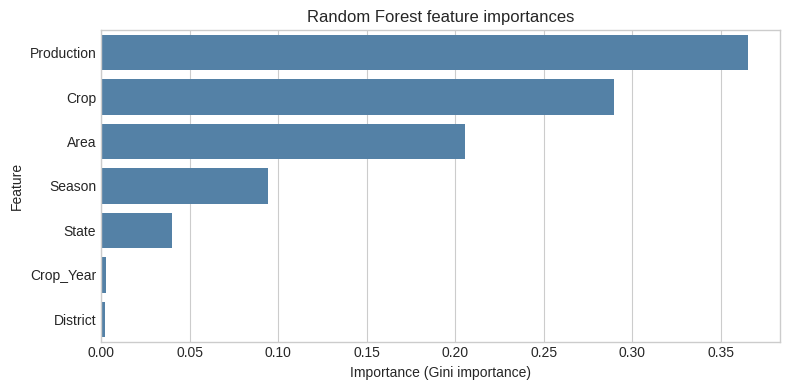

,0
Production,0.365283
Crop,0.289846
Area,0.205714
Season,0.094076
State,0.040106
Crop_Year,0.002883
District,0.002092


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names in the same order as train_X columns
feature_names = cat_cols + num_cols

rf_importances = pd.Series(rf.feature_importances_, index=feature_names)
rf_importances = rf_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_importances.values, y=rf_importances.index, color="steelblue")
plt.xlabel("Importance (Gini importance)")
plt.ylabel("Feature")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

rf_importances

- Production, Crop and Area are the most important predictors, showing that realised output, crop type and cultivated area dominate the model’s yield decisions.
- Season and State also contribute, while Crop_Year and District have much smaller importances, suggesting that temporal trends and fine‑grained district identity add only modest extra information beyond the main agronomic factors.

### 10.2 Feature importance for the best model

Computing permutation importance for HistGradientBoostingRegressor...


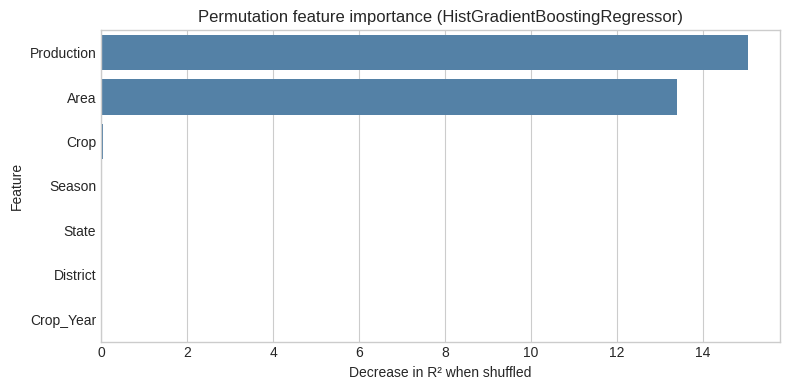

,0
Production,15.042334
Area,13.395510
Crop,0.045777
Season,0.026907
State,0.004808
District,0.000751
Crop_Year,0.000000


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names in the same order as train_X columns
feature_names = cat_cols + num_cols

print("Computing permutation importance for HistGradientBoostingRegressor...")
perm_result = permutation_importance(
    gb,
    X=test_X,
    y=test_y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

gb_importances = pd.Series(perm_result.importances_mean, index=feature_names)
gb_importances = gb_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=gb_importances.values, y=gb_importances.index, color="steelblue")
plt.xlabel("Decrease in R² when shuffled")
plt.ylabel("Feature")
plt.title("Permutation feature importance (HistGradientBoostingRegressor)")
plt.tight_layout()
plt.show()

gb_importances

- Permutation importance for the HistGradientBoostingRegressor shows that Production and Area have by far the largest impact on performance, while Crop, Season and State contribute smaller but non‑negligible effects.  
- District and Crop_Year have almost zero importance, suggesting that fine‑grained district identity and year‐to‐year variation add little beyond the main spatial, crop and scale variables already captured by the model.

## 11. Notebook summary

- I cleaned the APY dataset by removing missing crops, non‑positive yields and extreme yield outliers, then created a temporal train/validation/test split.  
- Exploratory analysis showed strong skew in Area, Production and Yield, clear seasonal and spatial differences, and a gradual increase in average yield over time.  
- Using encoded categorical and numeric features, I trained Ridge, Random Forest and HistGradientBoosting models, finding that HistGradientBoostingRegressor achieved the best test performance (RMSE ≈ 2.1 t/ha, R² ≈ 0.97).  
- Tuning and crop‑specific Random Forests did not outperform the boosted model, and permutation importance for HistGradientBoosting highlighted Production and Area as the dominant drivers of predicted yield, with smaller contributions from Crop, Season and State.